# CS 679 Project – PINN for European Call Option Pricing
Reproduction and Extensions of Socaciu & Pascu (2025)

In [8]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [9]:
# Parameters from the paper
Strike  = 50.0
T       = 1.0
sigma   = 0.2
r       = 0.05
t0      = 0.0
S0      = 10.0
SMax    = 10 * S0
delta_S = 10.0
n_col   = 1000
# Changed from paper defaults to improve convergence and boundary accuracy
epochs  = 20000   # original: 10000
delta_t = 1 / 128 # original: 1/52 — finer time grid stabilises S≈0 region


## Data Preparation

In [10]:
def payoff(s):
    return np.maximum(s - Strike, 0.0)

# Initial condition: terminal payoff at t = T
S1 = np.arange(S0, SMax + 1e-9, delta_S)
u1 = payoff(S1)
t1 = np.full_like(S1, T)

# Boundary condition: lower boundary at S = 0
t2 = np.arange(t0, T, delta_t)
S2 = np.zeros_like(t2)
u2 = np.zeros_like(t2)

# IC tensors
S_ic = torch.tensor(S1.reshape(-1, 1).astype(np.float32), device=device)
t_ic = torch.tensor(t1.reshape(-1, 1).astype(np.float32), device=device)
u_ic = torch.tensor(u1.reshape(-1, 1).astype(np.float32), device=device)

# BC tensors (lower boundary)
S_bc = torch.tensor(S2.reshape(-1, 1).astype(np.float32), device=device)
t_bc_data = torch.tensor(t2.reshape(-1, 1).astype(np.float32), device=device)
u_bc = torch.tensor(u2.reshape(-1, 1).astype(np.float32), device=device)

print(f'IC points: {len(S1)}  BC points: {len(S2)}')


IC points: 10  BC points: 128


## Model and Loss Definition

In [11]:
class Net(nn.Module):
    def __init__(self, activation=None):
        super().__init__()
        act = activation if activation is not None else nn.Tanh()
        self.net = nn.Sequential(
            nn.Linear(2, 20), act,
            nn.Linear(20, 20), act,
            nn.Linear(20, 1),
        )

    def forward(self, S, t):
        return self.net(torch.cat([S, t], dim=1))


def pde_loss(model, S, t):
    """Black-Scholes PDE residual on interior collocation points."""
    S = S.requires_grad_(True)
    t = t.requires_grad_(True)
    u = model(S, t)
    u_t  = torch.autograd.grad(u,   t,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_S  = torch.autograd.grad(u,   S,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_SS = torch.autograd.grad(u_S, S,  grad_outputs=torch.ones_like(u_S), create_graph=True)[0]
    residual = u_t + 0.5 * sigma**2 * S**2 * u_SS + r * S * u_S - r * u
    return torch.mean(residual ** 2)


def ic_loss(model, S_ic, t_ic, u_ic):
    """Terminal condition: u(S, T) = payoff(S)."""
    return torch.mean((model(S_ic, t_ic) - u_ic) ** 2)


def bc_loss(model, S_bc, t_bc, u_bc):
    """Lower boundary condition: u(0, t) = 0."""
    return torch.mean((model(S_bc, t_bc) - u_bc) ** 2)


def right_bc_loss(model, t_rbc):
    """Upper boundary condition: u(Smax, t) = Smax - K*exp(-r*(T-t))."""
    S_rbc  = torch.full_like(t_rbc, SMax)
    u_pred = model(S_rbc, t_rbc)
    u_true = SMax - Strike * torch.exp(-r * (T - t_rbc))
    return torch.mean((u_pred - u_true) ** 2)


def bs_call(S, K, tau, r, sigma):
    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
        d2 = d1 - sigma * np.sqrt(tau)
        price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    return np.where(S > 0, price, 0.0)


def evaluate(model, name):
    model.eval()
    t_test = np.zeros_like(S_test_np)
    with torch.no_grad():
        u_pred = model(torch.tensor(S_test_np, device=device),
                       torch.tensor(t_test,    device=device)).cpu().numpy().flatten()
    err    = np.abs(u_pred - bs_prices)
    mae    = err.mean()
    rel_l2 = np.linalg.norm(u_pred - bs_prices) / np.linalg.norm(bs_prices)
    print(f'{name:40s}  MAE: {mae:.4f}  Relative L2: {rel_l2:.4f}')
    return u_pred, err


S_test_np = np.linspace(0, 100, 200).reshape(-1, 1).astype(np.float32)
bs_prices  = bs_call(S_test_np.flatten(), Strike, T, r, sigma)


## Baseline: PINN vs MLP
Same architecture and boundary data. MLP uses only IC and BC loss; PINN additionally enforces the Black-Scholes PDE residual on random interior points.

In [5]:
def train_baseline(model, use_pde=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col = torch.FloatTensor(n_col, 1).uniform_(0, SMax).to(device)
        t_col = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        loss  = ic_loss(model, S_ic, t_ic, u_ic) + bc_loss(model, S_bc, t_bc_data, u_bc)
        if use_pde:
            loss = loss + pde_loss(model, S_col, t_col)
        loss.backward()
        optimizer.step()
        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.5f}')

print('Training PINN...')
pinn_baseline = Net().to(device)
train_baseline(pinn_baseline, use_pde=True)

print('\nTraining MLP...')
torch.manual_seed(42)
mlp = Net().to(device)
train_baseline(mlp, use_pde=False)


Training PINN...
  epoch     0  loss: 553.60876
  epoch  2000  loss: 37.78073
  epoch  4000  loss: 2.90104
  epoch  6000  loss: 0.28918
  epoch  8000  loss: 0.07573
  epoch 10000  loss: 0.04251
  epoch 12000  loss: 0.01807
  epoch 14000  loss: 0.01292
  epoch 16000  loss: 0.00997
  epoch 18000  loss: 0.02037

Training MLP...
  epoch     0  loss: 553.60822
  epoch  2000  loss: 37.60923
  epoch  4000  loss: 2.11561
  epoch  6000  loss: 0.00471
  epoch  8000  loss: 0.00084
  epoch 10000  loss: 0.00042
  epoch 12000  loss: 0.00015
  epoch 14000  loss: 0.00114
  epoch 16000  loss: 0.00007
  epoch 18000  loss: 0.00006


In [6]:
u_pinn_base, err_pinn_base = evaluate(pinn_baseline, 'PINN (baseline)')
u_mlp,       err_mlp       = evaluate(mlp,           'MLP (no PDE loss)')


PINN (baseline)                           MAE: 0.5700  Relative L2: 0.0486
MLP (no PDE loss)                         MAE: 19.1262  Relative L2: 1.0915


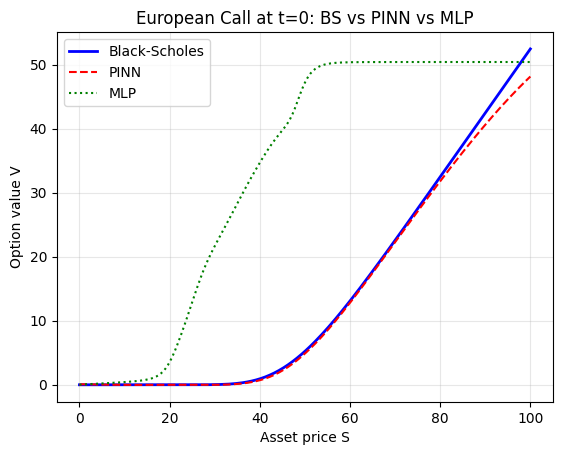

In [7]:
plt.figure()
plt.plot(S_test_np, bs_prices,   'b-',  lw=2,   label='Black-Scholes')
plt.plot(S_test_np, u_pinn_base, 'r--', lw=1.5, label='PINN')
plt.plot(S_test_np, u_mlp,       'g:',  lw=1.5, label='MLP')
plt.title('European Call at t=0: BS vs PINN vs MLP')
plt.xlabel('Asset price S')
plt.ylabel('Option value V')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pricing_baseline.png', dpi=150)
plt.show()


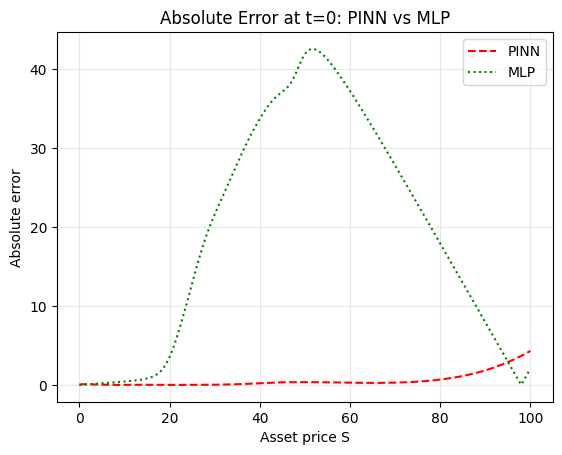

In [8]:
plt.figure()
plt.plot(S_test_np, err_pinn_base, 'r--', lw=1.5, label='PINN')
plt.plot(S_test_np, err_mlp,       'g:',  lw=1.5, label='MLP')
plt.title('Absolute Error at t=0: PINN vs MLP')
plt.xlabel('Asset price S')
plt.ylabel('Absolute error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('error_baseline.png', dpi=150)
plt.show()


## Extension 1: Right Boundary Condition
The baseline enforces only the lower boundary $u(0,t)=0$ and the terminal payoff. For deep in-the-money calls the correct upper boundary is:

$$u(S_{\max}, t) \approx S_{\max} - K e^{-r(T-t)}$$

We add this as an additional loss term and compare against the baseline PINN.

In [9]:
def train_right_bc(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col  = torch.FloatTensor(n_col, 1).uniform_(0, SMax).to(device)
        t_col  = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        t_rbc  = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        loss   = (ic_loss(model, S_ic, t_ic, u_ic)
                  + bc_loss(model, S_bc, t_bc_data, u_bc)
                  + pde_loss(model, S_col, t_col)
                  + right_bc_loss(model, t_rbc))
        loss.backward()
        optimizer.step()
        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.5f}')

print('Training PINN + Right BC...')
torch.manual_seed(42)
pinn_rbc = Net().to(device)
train_right_bc(pinn_rbc)


Training PINN + Right BC...
  epoch     0  loss: 3190.42529
  epoch  2000  loss: 284.52200
  epoch  4000  loss: 16.18080
  epoch  6000  loss: 0.62862
  epoch  8000  loss: 0.14452
  epoch 10000  loss: 0.13295
  epoch 12000  loss: 0.06843
  epoch 14000  loss: 0.03780
  epoch 16000  loss: 0.09897
  epoch 18000  loss: 0.17348


In [10]:
u_pinn_rbc, err_pinn_rbc = evaluate(pinn_rbc,      'PINN + Right BC')
_,          _            = evaluate(pinn_baseline, 'PINN (baseline)')


PINN + Right BC                           MAE: 0.0986  Relative L2: 0.0062
PINN (baseline)                           MAE: 0.5700  Relative L2: 0.0486


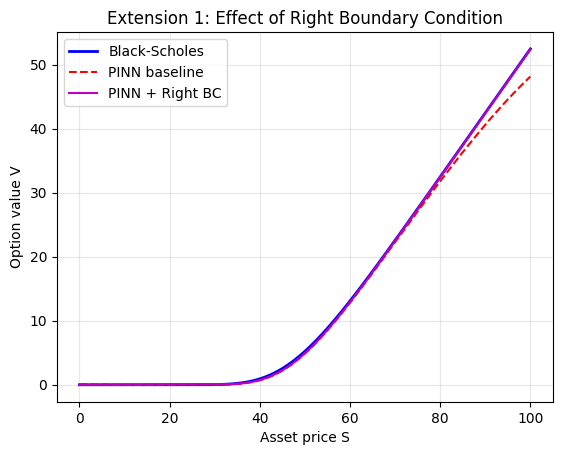

In [12]:
plt.figure()
plt.plot(S_test_np, bs_prices,   'b-',  lw=2,   label='Black-Scholes')
plt.plot(S_test_np, u_pinn_base, 'r--', lw=1.5, label='PINN baseline')
plt.plot(S_test_np, u_pinn_rbc,  'm-',  lw=1.5, label='PINN + Right BC')
plt.title('Extension 1: Effect of Right Boundary Condition')
plt.xlabel('Asset price S')
plt.ylabel('Option value V')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pricing_ext1_rbc.png', dpi=150)
plt.show()


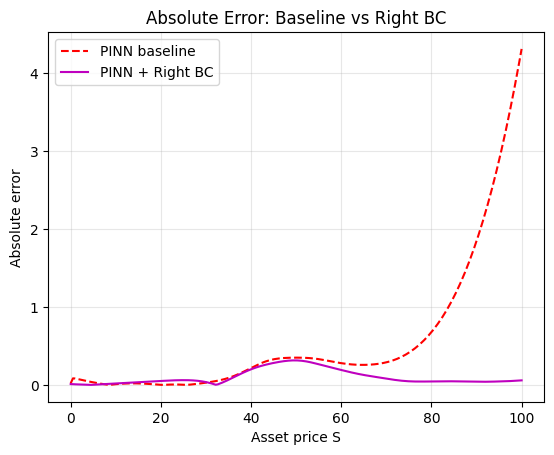

In [13]:
plt.figure()
plt.plot(S_test_np, err_pinn_base, 'r--', lw=1.5, label='PINN baseline')
plt.plot(S_test_np, err_pinn_rbc,  'm-',  lw=1.5, label='PINN + Right BC')
plt.title('Absolute Error: Baseline vs Right BC')
plt.xlabel('Asset price S')
plt.ylabel('Absolute error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('error_ext1_rbc.png', dpi=150)
plt.show()


## Extension 2: Residual-based Adaptive Refinement (RAR)
Uniform random collocation treats all regions equally, but the PDE residual is largest near at-the-money ($S \approx K$) where the solution changes most rapidly. RAR periodically replaces the lowest-residual collocation points with new ones sampled proportionally to the residual magnitude, keeping the pool size fixed.

We compare the baseline PINN against PINN + RAR to isolate the effect of adaptive sampling.

In [19]:
def train_rar(model, rar_interval=250, rar_k=300, n_cand=5000):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # manage pool as numpy to avoid tensor graph state issues
    S_pool = np.random.uniform(0, SMax, (n_col, 1)).astype(np.float32)
    t_pool = np.random.uniform(t0, T,   (n_col, 1)).astype(np.float32)

    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col = torch.tensor(S_pool).to(device)
        t_col = torch.tensor(t_pool).to(device)
        loss  = (ic_loss(model, S_ic, t_ic, u_ic)
                 + bc_loss(model, S_bc, t_bc_data, u_bc)
                 + pde_loss(model, S_col, t_col))
        loss.backward()
        optimizer.step()

        if (epoch + 1) % rar_interval == 0:
            model.eval()

            def get_residual_np(S_np, t_np):
                S_ = torch.tensor(S_np).to(device).requires_grad_(True)
                t_ = torch.tensor(t_np).to(device).requires_grad_(True)
                u_ = model(S_, t_)
                u_t  = torch.autograd.grad(u_,  t_, grad_outputs=torch.ones_like(u_),  create_graph=True)[0]
                u_S  = torch.autograd.grad(u_,  S_, grad_outputs=torch.ones_like(u_),  create_graph=True)[0]
                u_SS = torch.autograd.grad(u_S, S_, grad_outputs=torch.ones_like(u_S), create_graph=True)[0]
                res  = u_t + 0.5 * sigma**2 * S_**2 * u_SS + r * S_ * u_S - r * u_
                return res.detach().abs().squeeze().cpu().numpy()

            res_pool = get_residual_np(S_pool, t_pool)
            low_idx  = np.argsort(res_pool)[:rar_k]
            S_cand   = np.random.uniform(0, SMax, (n_cand, 1)).astype(np.float32)
            t_cand   = np.random.uniform(t0, T,   (n_cand, 1)).astype(np.float32)
            res_cand = get_residual_np(S_cand, t_cand)
            w        = res_cand / res_cand.sum()
            new_idx  = np.random.choice(n_cand, size=rar_k, replace=False, p=w)
            S_pool[low_idx] = S_cand[new_idx]
            t_pool[low_idx] = t_cand[new_idx]
            model.train()

        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.5f}')

    return S_pool, t_pool


print('Training PINN + RAR...')
torch.manual_seed(42)
pinn_rar = Net().to(device)
final_S_col, final_t_col = train_rar(pinn_rar)


Training PINN + RAR...
  epoch     0  loss: 553.60876
  epoch  2000  loss: 38.06842
  epoch  4000  loss: 3.09463
  epoch  6000  loss: 0.33464
  epoch  8000  loss: 0.12250
  epoch 10000  loss: 0.06190
  epoch 12000  loss: 0.01972
  epoch 14000  loss: 0.09350
  epoch 16000  loss: 0.01102
  epoch 18000  loss: 0.00864


In [20]:
u_pinn_rar, err_pinn_rar = evaluate(pinn_rar,      'PINN + RAR')
_,          _            = evaluate(pinn_baseline, 'PINN (baseline)')


PINN + RAR                                MAE: 0.2100  Relative L2: 0.0188
PINN (baseline)                           MAE: 0.5700  Relative L2: 0.0486


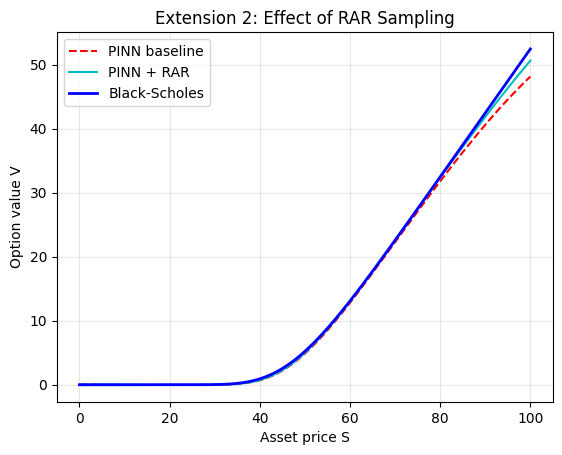

In [21]:
plt.figure()
plt.plot(S_test_np, u_pinn_base, 'r--', lw=1.5, label='PINN baseline')
plt.plot(S_test_np, u_pinn_rar,  'c-',  lw=1.5, label='PINN + RAR')
plt.plot(S_test_np, bs_prices,   'b-',  lw=2,   label='Black-Scholes')
plt.title('Extension 2: Effect of RAR Sampling')
plt.xlabel('Asset price S')
plt.ylabel('Option value V')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pricing_ext2_rar.png', dpi=150)
plt.show()


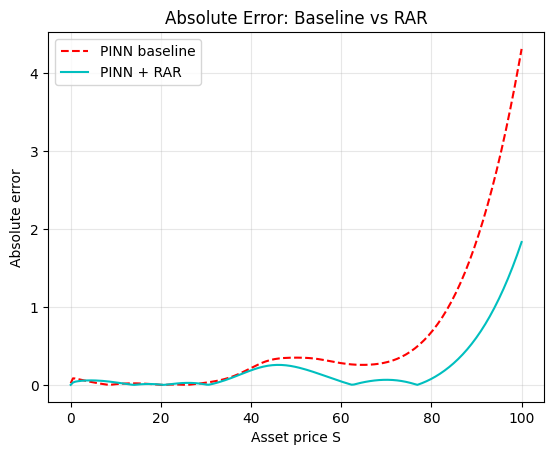

In [22]:
plt.figure()
plt.plot(S_test_np, err_pinn_base, 'r--', lw=1.5, label='PINN baseline')
plt.plot(S_test_np, err_pinn_rar,  'c-',  lw=1.5, label='PINN + RAR')
plt.title('Absolute Error: Baseline vs RAR')
plt.xlabel('Asset price S')
plt.ylabel('Absolute error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('error_ext2_rar.png', dpi=150)
plt.show()


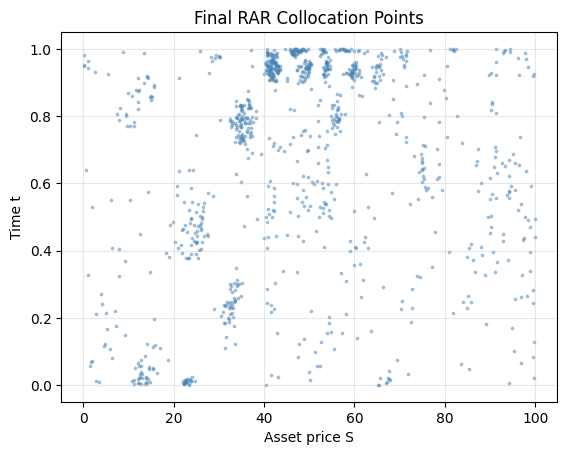

In [23]:
plt.figure()
plt.scatter(final_S_col.flatten(), final_t_col.flatten(),
            s=3, alpha=0.4, color='steelblue')
plt.title('Final RAR Collocation Points')
plt.xlabel('Asset price S')
plt.ylabel('Time t')
plt.grid(True, alpha=0.3)
plt.savefig('rar_collocation_points.png', dpi=150)
plt.show()


## Extension 3: Swish Activation Function
The baseline uses Tanh. We compare against Swish ($x \cdot \sigma(x)$), which is smooth and has non-zero gradient everywhere. Note: ReLU cannot be used because the Black-Scholes PDE requires $\hat{u}_{SS}$, and ReLU's second derivative is zero everywhere.

In [24]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


def train_swish(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col = torch.FloatTensor(n_col, 1).uniform_(0, SMax).to(device)
        t_col = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        loss  = (ic_loss(model, S_ic, t_ic, u_ic)
                 + bc_loss(model, S_bc, t_bc_data, u_bc)
                 + pde_loss(model, S_col, t_col))
        loss.backward()
        optimizer.step()
        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.5f}')


print('Training PINN + Swish...')
torch.manual_seed(42)
pinn_swish = Net(activation=Swish()).to(device)
train_swish(pinn_swish)


Training PINN + Swish...
  epoch     0  loss: 615.47089
  epoch  2000  loss: 0.39758
  epoch  4000  loss: 0.32004
  epoch  6000  loss: 0.21098
  epoch  8000  loss: 0.12573
  epoch 10000  loss: 0.11346
  epoch 12000  loss: 0.06528
  epoch 14000  loss: 0.04395
  epoch 16000  loss: 0.03827
  epoch 18000  loss: 0.03290


In [25]:
u_pinn_swish, err_pinn_swish = evaluate(pinn_swish,    'PINN + Swish')
_,            _              = evaluate(pinn_baseline, 'PINN + Tanh (baseline)')


PINN + Swish                              MAE: 0.1686  Relative L2: 0.0137
PINN + Tanh (baseline)                    MAE: 0.5700  Relative L2: 0.0486


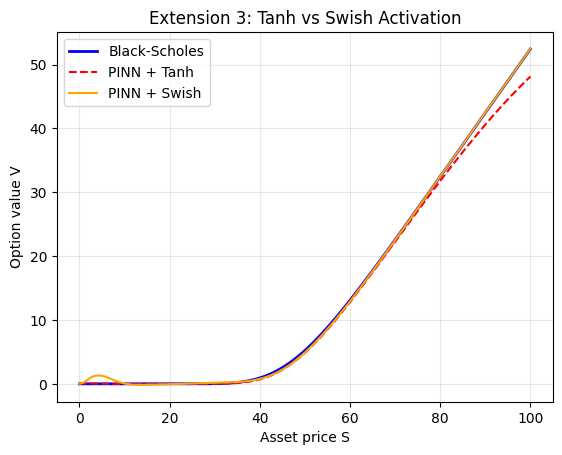

In [26]:
plt.figure()
plt.plot(S_test_np, bs_prices,    'b-',     lw=2,   label='Black-Scholes')
plt.plot(S_test_np, u_pinn_base,  'r--',    lw=1.5, label='PINN + Tanh')
plt.plot(S_test_np, u_pinn_swish, 'orange', lw=1.5, label='PINN + Swish')
plt.title('Extension 3: Tanh vs Swish Activation')
plt.xlabel('Asset price S')
plt.ylabel('Option value V')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pricing_ext3_swish.png', dpi=150)
plt.show()


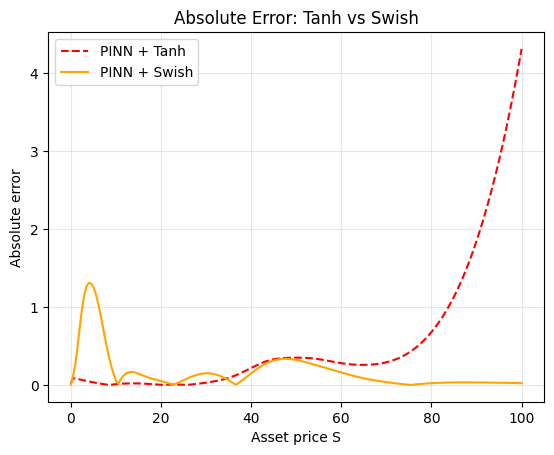

In [27]:
plt.figure()
plt.plot(S_test_np, err_pinn_base,  'r--',    lw=1.5, label='PINN + Tanh')
plt.plot(S_test_np, err_pinn_swish, 'orange', lw=1.5, label='PINN + Swish')
plt.title('Absolute Error: Tanh vs Swish')
plt.xlabel('Asset price S')
plt.ylabel('Absolute error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('error_ext3_swish.png', dpi=150)
plt.show()


## Final Model: Right BC + Tanh vs Right BC + Swish
We combine Extension 1 (Right BC) with Extension 3 (activation function), training two variants to determine the better configuration.

Swish performs better than Tanh when no right boundary condition is enforced, because its non-saturating gradient naturally suppresses error growth at large $S$. However, once the right BC is explicitly enforced, this advantage disappears and Tanh converges more cleanly due to a simpler loss landscape. We therefore select **Right BC + Tanh** as the final model.

In [28]:
def train_final(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col = torch.FloatTensor(n_col, 1).uniform_(0, SMax).to(device)
        t_col = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        t_rbc = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        loss  = (ic_loss(model, S_ic, t_ic, u_ic)
                 + bc_loss(model, S_bc, t_bc_data, u_bc)
                 + pde_loss(model, S_col, t_col)
                 + right_bc_loss(model, t_rbc))
        loss.backward()
        optimizer.step()
        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.5f}')


print('Training Final (Right BC + Tanh)...')
torch.manual_seed(42)
pinn_final_tanh = Net().to(device)
train_final(pinn_final_tanh)

print('\nTraining Final (Right BC + Swish)...')
torch.manual_seed(42)
pinn_final_swish = Net(activation=Swish()).to(device)
train_final(pinn_final_swish)


Training Final (Right BC + Tanh)...
  epoch     0  loss: 3190.42529
  epoch  2000  loss: 284.52200
  epoch  4000  loss: 16.18080
  epoch  6000  loss: 0.62862
  epoch  8000  loss: 0.14452
  epoch 10000  loss: 0.13295
  epoch 12000  loss: 0.06843
  epoch 14000  loss: 0.03780
  epoch 16000  loss: 0.09897
  epoch 18000  loss: 0.17348

Training Final (Right BC + Swish)...
  epoch     0  loss: 3490.41406
  epoch  2000  loss: 0.52857
  epoch  4000  loss: 0.35315
  epoch  6000  loss: 0.29593
  epoch  8000  loss: 0.26950
  epoch 10000  loss: 0.17495
  epoch 12000  loss: 0.15728
  epoch 14000  loss: 0.11904
  epoch 16000  loss: 0.22251
  epoch 18000  loss: 0.07844


In [29]:
u_final_tanh,  err_final_tanh  = evaluate(pinn_final_tanh,  'Final: Right BC + Tanh')
u_final_swish, err_final_swish = evaluate(pinn_final_swish, 'Final: Right BC + Swish')
_,             _               = evaluate(pinn_baseline,    'PINN (baseline)')


Final: Right BC + Tanh                    MAE: 0.0986  Relative L2: 0.0062
Final: Right BC + Swish                   MAE: 0.1391  Relative L2: 0.0107
PINN (baseline)                           MAE: 0.5700  Relative L2: 0.0486


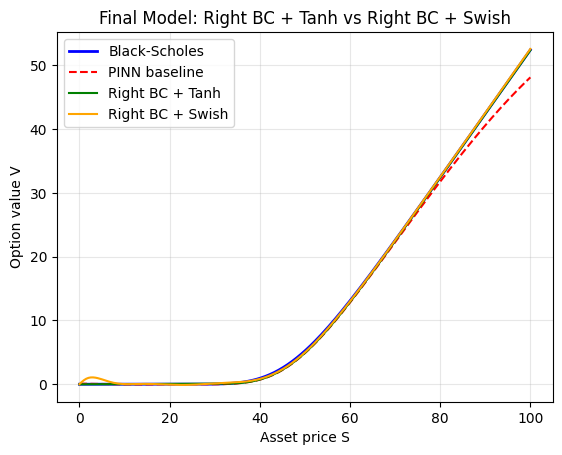

In [30]:
plt.figure()
plt.plot(S_test_np, bs_prices,      'b-',     lw=2,   label='Black-Scholes')
plt.plot(S_test_np, u_pinn_base,    'r--',    lw=1.5, label='PINN baseline')
plt.plot(S_test_np, u_final_tanh,   'g-',     lw=1.5, label='Right BC + Tanh')
plt.plot(S_test_np, u_final_swish,  'orange', lw=1.5, label='Right BC + Swish')
plt.title('Final Model: Right BC + Tanh vs Right BC + Swish')
plt.xlabel('Asset price S')
plt.ylabel('Option value V')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pricing_final.png', dpi=150)
plt.show()


Figure 1

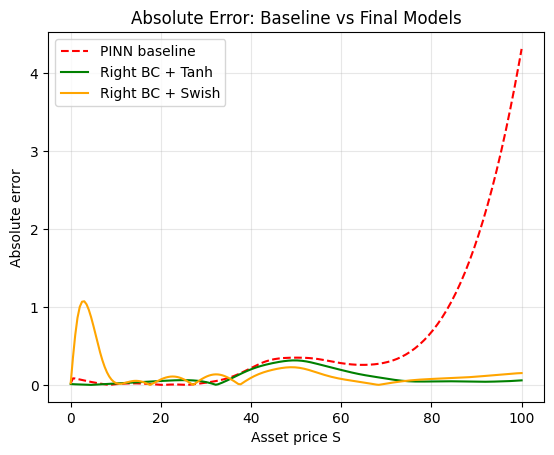

In [31]:
plt.figure()
plt.plot(S_test_np, err_pinn_base,   'r--',    lw=1.5, label='PINN baseline')
plt.plot(S_test_np, err_final_tanh,  'g-',     lw=1.5, label='Right BC + Tanh')
plt.plot(S_test_np, err_final_swish, 'orange', lw=1.5, label='Right BC + Swish')
plt.title('Absolute Error: Baseline vs Final Models')
plt.xlabel('Asset price S')
plt.ylabel('Absolute error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('error_final.png', dpi=150)
plt.show()


Figure 2

In [32]:
# Right BC + Tanh is selected as the final model
pinn_final = pinn_final_tanh


## Extension 4: European Put and Put-Call Parity
We train a Put PINN using the same configuration as the final Call model (Right BC + Tanh), with the put-specific boundary conditions:

- Terminal condition: $u(S, T) = \max(K - S, 0)$
- Lower boundary: $u(0, t) = K e^{-r(T-t)}$
- Upper boundary: $u(S_{\max}, t) = 0$

We then verify Put-Call Parity as a model-free correctness check:

$$C(S,t) - P(S,t) = S - K e^{-r(T-t)}$$

If both PINNs are correct, the left and right sides should match across all $S$.

In [33]:
def payoff_put(s):
    return np.maximum(Strike - s, 0.0)

# IC: terminal payoff for put
u1_put = payoff_put(S1)
S_ic_put = S_ic
t_ic_put = t_ic
u_ic_put = torch.tensor(u1_put.reshape(-1, 1).astype(np.float32), device=device)

# BC: lower boundary u(0,t) = K*exp(-r*(T-t))
u2_put   = Strike * np.exp(-r * (T - t2))
u_bc_put = torch.tensor(u2_put.reshape(-1, 1).astype(np.float32), device=device)

def right_bc_loss_put(model, t_rbc):
    """Upper boundary for put: u(Smax, t) = 0."""
    S_rbc  = torch.full_like(t_rbc, SMax)
    u_pred = model(S_rbc, t_rbc)
    return torch.mean(u_pred ** 2)


In [34]:
def train_put(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col = torch.FloatTensor(n_col, 1).uniform_(0, SMax).to(device)
        t_col = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        t_rbc = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        loss  = (ic_loss(model, S_ic_put, t_ic_put, u_ic_put)
                 + bc_loss(model, S_bc, t_bc_data, u_bc_put)
                 + pde_loss(model, S_col, t_col)
                 + right_bc_loss_put(model, t_rbc))
        loss.backward()
        optimizer.step()
        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.5f}')


print('Training Put PINN (Right BC + Tanh)...')
torch.manual_seed(42)
pinn_put = Net().to(device)
train_put(pinn_put)


Training Put PINN (Right BC + Tanh)...
  epoch     0  loss: 2696.12256
  epoch  2000  loss: 166.61255
  epoch  4000  loss: 1.78197
  epoch  6000  loss: 0.45682
  epoch  8000  loss: 0.28589
  epoch 10000  loss: 0.18821
  epoch 12000  loss: 0.11482
  epoch 14000  loss: 0.08256
  epoch 16000  loss: 0.06428
  epoch 18000  loss: 0.05641


In [68]:
pinn_final.eval()
pinn_put.eval()

t_zero = np.zeros_like(S_test_np)
with torch.no_grad():
    u_call = pinn_final(torch.tensor(S_test_np, device=device),
                        torch.tensor(t_zero,    device=device)).cpu().numpy().flatten()
    u_put  = pinn_put(torch.tensor(S_test_np,   device=device),
                      torch.tensor(t_zero,      device=device)).cpu().numpy().flatten()

bs_put = np.maximum(Strike * np.exp(-r * T) - S_test_np.flatten() + bs_prices, 0.0)

lhs          = u_call - u_put
rhs          = S_test_np.flatten() - Strike * np.exp(-r * T)
parity_error = np.abs(lhs - rhs)
mask = S_test_np.flatten() > 10
print(f'Put-Call Parity MAE (S>10): {parity_error[mask].mean():.4f}  Max: {parity_error[mask].max():.4f}')

Put-Call Parity MAE (S>10): 0.2611  Max: 0.6634


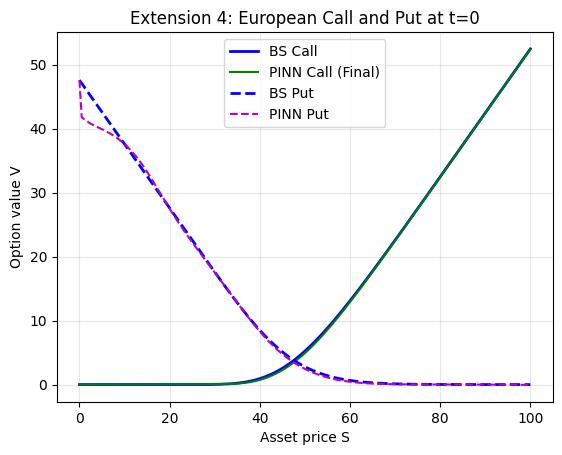

In [45]:
plt.figure()
plt.plot(S_test_np, bs_prices, 'b-',  lw=2,   label='BS Call')
plt.plot(S_test_np, u_call,    'g-',  lw=1.5, label='PINN Call (Final)')
plt.plot(S_test_np, bs_put,    'b--', lw=2,   label='BS Put')
plt.plot(S_test_np, u_put,     'm--', lw=1.5, label='PINN Put')
plt.title('Extension 4: European Call and Put at t=0')
plt.xlabel('Asset price S')
plt.ylabel('Option value V')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pricing_ext4_put.png', dpi=150)
plt.show()


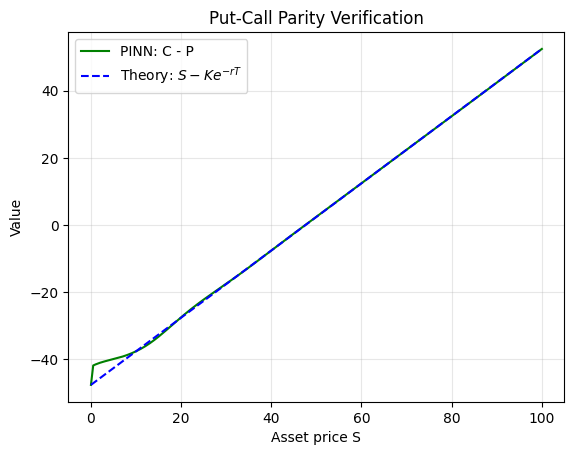

In [46]:
plt.figure()
plt.plot(S_test_np, lhs, 'g-',  lw=1.5, label='PINN: C - P')
plt.plot(S_test_np, rhs, 'b--', lw=1.5, label=r'Theory: $S - Ke^{-rT}$')
plt.title('Put-Call Parity Verification')
plt.xlabel('Asset price S')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('parity_ext4.png', dpi=150)
plt.show()


Figure 3

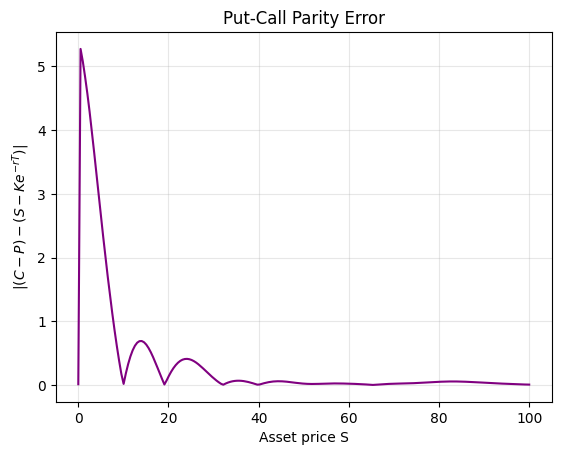

In [47]:
plt.figure()
plt.plot(S_test_np, parity_error, color='purple', lw=1.5)
plt.title('Put-Call Parity Error')
plt.xlabel('Asset price S')
plt.ylabel(r'$|(C - P) - (S - Ke^{-rT})|$')
plt.grid(True, alpha=0.3)
plt.savefig('parity_error_ext4.png', dpi=150)
plt.show()


## Extension 5: American Put Option

Unlike the European put, an American put may be exercised at any time $t \le T$. The value $V_{\text{Am}}(t, S)$ satisfies a complementarity problem: either the Black-Scholes operator is zero (hold) or the option is at its intrinsic value (exercise), with at least one always binding:

$$
\left(\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S} - rV\right) \cdot \bigl(\max(K-S,0) - V\bigr) = 0
$$

Boundary conditions:

| | Value |
|---|---|
| Terminal $t=T$ | $\max(K-S,0)$ |
| Lower $S=0$ | $K$ |
| Upper $S=S_{\max}$ | $0$ |

The PINN loss adds two terms on top of the standard IC/BC losses: a **complementarity loss** enforcing the product condition above, and an **early-exercise penalty** that pushes $V \ge \max(K-S,0)$.

In [12]:
# Terminal: put payoff; 
# lower BC: full strike when S->0; 
# upper BC: worthless at Smax
u_ic_am = torch.tensor(np.maximum(Strike - S1, 0.0).reshape(-1,1).astype(np.float32), device=device)
u_bc_am = torch.tensor(np.full_like(t2, Strike).reshape(-1,1).astype(np.float32),     device=device)

def am_upper_bc_loss(model, t_rbc):
    # V(Smax, t) = 0
    return torch.mean(model(torch.full_like(t_rbc, SMax), t_rbc) ** 2)


In [13]:
def am_complementarity_loss(model, S, t):
    # BS_operator * (max(K-S,0) - V) = 0 on interior points
    S = S.requires_grad_(True); t = t.requires_grad_(True)
    V    = model(S, t)
    V_t  = torch.autograd.grad(V,   t,  grad_outputs=torch.ones_like(V),   create_graph=True)[0]
    V_S  = torch.autograd.grad(V,   S,  grad_outputs=torch.ones_like(V),   create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S,  grad_outputs=torch.ones_like(V_S), create_graph=True)[0]
    BS        = V_t + 0.5*sigma**2*S**2*V_SS + r*S*V_S - r*V
    intrinsic = torch.clamp(Strike - S, min=0.0)
    return torch.mean((BS * (intrinsic - V))**2)

def am_penalty_loss(model, S, t):
    # Penalise V < max(K-S,0)
    V         = model(S, t)
    intrinsic = torch.clamp(Strike - S.detach(), min=0.0)
    return torch.mean(torch.clamp(intrinsic - V, min=0.0)**2)


In [14]:
def train_american_put(model, lam=5.0):
    # lam weights the early-exercise penalty relative to the complementarity loss
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_col = torch.FloatTensor(n_col, 1).uniform_(0, SMax).to(device)
        t_col = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        t_ubc = torch.FloatTensor(n_col, 1).uniform_(t0, T).to(device)
        loss = (ic_loss(model, S_ic, t_ic, u_ic_am)            # terminal payoff
              + bc_loss(model, S_bc, t_bc_data, u_bc_am)       # lower BC
              + am_upper_bc_loss(model, t_ubc)                 # upper BC
              + am_complementarity_loss(model, S_col, t_col)   # complementarity
              + lam * am_penalty_loss(model, S_col, t_col))    # early-exercise
        loss.backward(); optimizer.step()
        if epoch % 2000 == 0:
            print(f'  epoch {epoch:5d}  loss: {loss.item():.6f}')

print('Training American Put PINN...')
torch.manual_seed(42)
pinn_am_put = Net().to(device)
train_american_put(pinn_am_put)


Training American Put PINN...
  epoch     0  loss: 4951.342773
  epoch  2000  loss: 321.091187
  epoch  4000  loss: 7.420767
  epoch  6000  loss: 1.349470
  epoch  8000  loss: 1.186531
  epoch 10000  loss: 1.012181
  epoch 12000  loss: 0.421320
  epoch 14000  loss: 0.275735
  epoch 16000  loss: 0.206387
  epoch 18000  loss: 0.162327


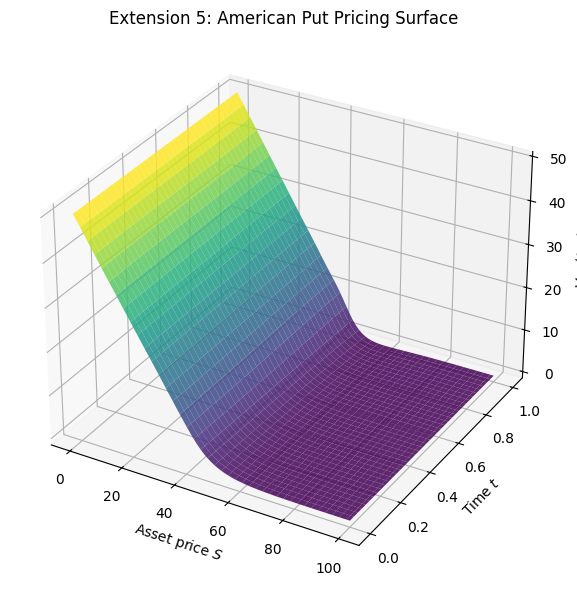

In [15]:
# Evaluate V(t, S) on a grid and plot the pricing surface
n_S, n_t = 80, 40
S_surf = np.linspace(0, SMax, n_S, dtype=np.float32)
t_surf = np.linspace(0, T,    n_t, dtype=np.float32)
SS, TT = np.meshgrid(S_surf, t_surf)

pinn_am_put.eval()
with torch.no_grad():
    V_surf = pinn_am_put(
        torch.tensor(SS.flatten().reshape(-1, 1), device=device),
        torch.tensor(TT.flatten().reshape(-1, 1), device=device)
    ).cpu().numpy().reshape(n_t, n_S)

fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(SS, TT, V_surf, cmap='viridis', alpha=0.85)
ax.set_xlabel('Asset price $S$')
ax.set_ylabel('Time $t$')
ax.set_zlabel('$V_{\\mathrm{Am}}(t,S)$')
ax.set_title('Extension 5: American Put Pricing Surface')
plt.tight_layout()
plt.savefig('surface_ext5_american_put.png', dpi=150)
plt.show()


Figure 4